# Fools-Gold ✨
### The 'golden cross' — when the 50-day average crosses above the 200-day, is it really a buy signal?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Generalises?: Not supported](https://img.shields.io/badge/Generalises%3F-Not_supported-8b949e?style=flat-square)

It's the single most-quoted pattern on financial TV: the **golden cross**, when a fast moving average (50-day) crosses *above* a slow one (200-day), supposedly signals a new bull market — and the **death cross** the reverse. Generations of chartists swear by it.

This is the desk's fourth idea from Kakushadze & Serur's *151 Trading Strategies* (strategies §3.11–3.13), and it's the textbook *folk* specimen. We prove our tools on a synthetic tape where we bake a real trend in (and a driftless null where a crossover can catch nothing), then point them at a basket of real ETFs — and find the golden cross is **fool's gold**: it shines on the one asset everyone quotes, and nowhere else.

> 📓 **Plain-language layer.** The Newey–West *t*, the alpha-vs-buy-and-hold and the parameter grid are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it; the core runs on a **synthetic** tape, so the real-ETF numbers (from [`../docs/results.md`](../docs/results.md)) are a measurement. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from fools_gold import data, cross, strategy, decompose, extension

# Offline synthetic close: a persistent-drift TREND (so a crossover can ride runs) and a driftless
# NULL (random walk). The real ETF verdict is in ../docs/results.md.
close, truth = data.synthetic_prices(trend_strength=0.0006, seed=21)   # the trend tape
close0, _    = data.synthetic_prices(trend_strength=0.0,    seed=21)   # the driftless null
print(f"{truth.n_bars} bars | baked trend_strength={truth.trend_strength} | null=0")


6048 bars | baked trend_strength=0.0006 | null=0


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Does the golden cross beat buy-and-hold? | 🟡 **On the S&P, barely; elsewhere, no.** It wins on **3 of 8** ETFs (median gain **-0.01**). |
| Is it skill, or just less exposure? | ⚪ **Mostly less exposure** — it sits in cash a lot (beta **0.52**); a plain cash blend captures most of the calm. |
| Does it generalise? | 🚫 **No.** It 'works' on **76%** of parameter pairs for the S&P and **0%** for a different index — a cherry-pick, not an edge. |

> Desk shorthand: **Signal `WEAK` · Tradability `MIRAGE` · Generalises? `NOT SUPPORTED`** — a trend filter dressed up as a magic buy signal.

## 1 · The claim 📣

The folk claim is specific and testable: **once you're in a 'golden' state, future returns are higher than in a 'death' state.** Not just "trends exist" — the crossover *event* is supposed to carry information. On our synthetic trending tape we baked a real trend in; split days by yesterday's crossover state and look at the next day's return:

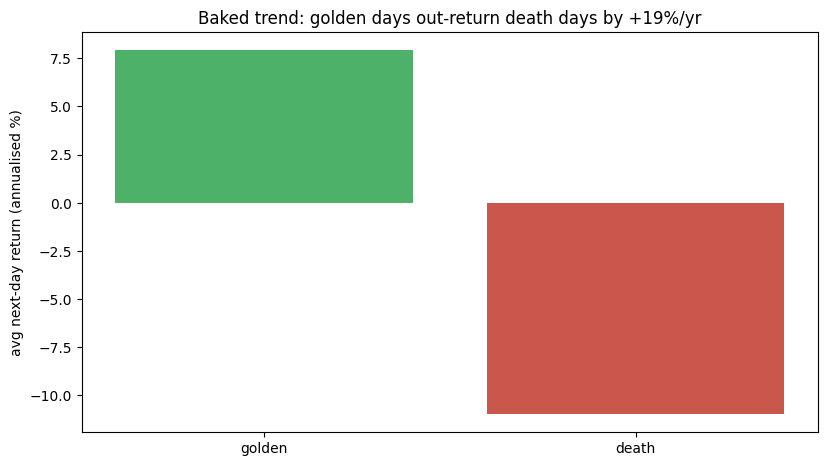

golden +8%/yr vs death -11%/yr; time golden 49%


In [2]:
sv = cross.signal_value(close)
fig, ax = plt.subplots()
ax.bar(['golden', 'death'], [sv['golden_ann_pct'], sv['death_ann_pct']], color=['#2ea44f','#c0392b'], alpha=.85)
ax.set_ylabel('avg next-day return (annualised %)')
ax.set_title(f"Baked trend: golden days out-return death days by {sv['spread_ann_pct']:+.0f}%/yr")
plt.show()
print(f"golden {sv['golden_ann_pct']:+.0f}%/yr vs death {sv['death_ann_pct']:+.0f}%/yr; time golden {sv['frac_golden']:.0%}")

## 2 · So what? 💰

If the crossover truly timed bull and bear markets, it would be the holy grail: ride the ups, dodge the crashes, beat buy-and-hold with less stress. That's exactly the promise sold in every "golden cross alert" headline. The catch the desk always checks: a rule that holds *cash* part of the time will *automatically* look calmer — so the only fair question is whether it beats buy-and-hold once you account for simply taking less risk.

## 3 · How we'd know 🔬

Four checks, up front:

1. **Is the crossover informative?** Golden-minus-death next-day spread, with a *t*-stat.
2. **Does it beat buy-and-hold**, net of cost — across many assets, not one?
3. **Is it more than de-risking?** Alpha & beta vs buy-and-hold; a risk-matched cash blend.
4. **Does it generalise** across parameters and assets? And the **null**: a random walk must yield nothing.

**Mirage line:** it beats buy-and-hold on only a handful of assets, the 'edge' is just lower exposure, and it falls apart at un-cherry-picked parameters.

## 4 · The teardown 🔧

### 4a · Trend tape vs null — and the random-walk trap
Run the crossover on both synthetic tapes. Watch the null carefully: a *single* random walk can drift by chance, making the crossover look good — the data-mining trap in miniature.

In [3]:
for label, c in [('trend', close), ('driftless null', close0)]:
    cmp = strategy.compare(c, cost_bps=2.0); sp = decompose.spread_tstat(c)
    print(f"{label:16s}: timing Sharpe {cmp['timing']['sharpe']:+.2f} vs B&H {cmp['buy_hold']['sharpe']:+.2f} "
          f"(gain {cmp['sharpe_gain']:+.2f}), golden−death t {sp['t_stat']:+.1f}")

trend           : timing Sharpe +0.34 vs B&H -0.12 (gain +0.46), golden−death t +2.9
driftless null  : timing Sharpe -0.15 vs B&H -0.17 (gain +0.02), golden−death t -0.1


### 4b · The real tape — fool's gold
On a basket of real ETFs (quoted from [`../docs/results.md`](../docs/results.md)):

- On **SPY** the golden−death spread is real (*t* = **+2.7**) and timing edges buy-and-hold (Sharpe **+0.65** vs **+0.55**, +0.10).
- But across **8** instruments it beats buy-and-hold on only **3**, median gain **-0.01** — a coin flip.
- On SPY the 'edge' is mostly *less exposure*: beta **0.52**, and a constant cash blend at the same average exposure captures most of the calm.
- It doesn't generalise: it beats buy-and-hold on **76%** of (fast, slow) pairs for SPY but **0%** for another index.

### 4c · And even on the S&P, it stopped working
The golden cross looked great when it dodged 2008 — and has *lagged* buy-and-hold through the long bull since, because it kept sitting out the dips.

On real SPY: first half Sharpe **+0.74** (timing) vs **+0.36** (buy-and-hold) — timing won by dodging the crash; second half **+0.57** vs **+0.76** — buy-and-hold won as the filter sat in cash through every dip. The 'signal' is a bet on *when* a crash happens to land, not a repeatable edge.

## 5 · The verdict 🧾

- **Weak & non-general** — significant golden−death spread only on the trending US indices; a coin flip across 8 assets.
- **Mostly de-risking** — low beta; a cash blend matches it.
- **Doesn't generalise** — works on 76% of params for SPY, 0% for another index.

> **Signal `WEAK` · Tradability `MIRAGE` · Generalises? `NOT SUPPORTED`.** A trend filter, re-discovered on the one asset everyone cherry-picks.

## 6 · Could you trade it? 💸

- **It barely beats buy-and-hold** where it 'works', and loses elsewhere — net of the cost of every whipsaw.
- **The calm is just cash.** You could replicate most of the lower drawdown by simply holding less and keeping the rest in T-bills — no crossover required.
- **You'd be timing the next crash.** Its whole record is dodging *one* bear market; miss the timing and you spend years underperforming in cash.

> Tradability **`MIRAGE`**; generalises? **`NOT SUPPORTED`** — the parameter grid ([`../docs/extension.md`](../docs/extension.md)) shows the cherry-pick.

## 7 · Going further 🚪

- **The parameter-robustness test** (beat 7 of the quants notebook + [`../docs/extension.md`](../docs/extension.md)): the % of (fast, slow) pairs that beat buy-and-hold, asset by asset — near-total on the trending index, zero elsewhere.
- **A real trend filter, done honestly.** Time-series momentum across many markets ([Study 20](../../20-freight-train/)) is the grown-up version; the single-asset 50/200 is its folk cartoon.
- **As a de-risking overlay** (à la [Study 16](../../16-storm-shy/)) rather than a buy signal — does a crossover add anything to inverse-vol sizing, or is it strictly worse?

PRs welcome — find an asset/parameter where it survives out-of-sample, or show it's strictly a worse trend filter than the alternatives.